# Forecast Validation

The baseline forecasting notebook compared Naive, Seasonal Naive, 7-Day SMA, and ETS using one 28-day test period. ETS produced the lowest errors, but one test window is not enough to confirm that it performs reliably over time.

This notebook uses rolling-origin validation to evaluate the models across multiple historical periods.

Main objectives:

1. Create repeated calendar-month validation windows.
2. Refit each model using only the data available before each window.
3. Compare Naive, Seasonal Naive, 7-Day SMA, and ETS using MAE, RMSE, and WAPE.
4. Measure model consistency across categories and validation periods.
5. Build a reusable validation framework for later statistical and machine-learning models.
6. Select a leading candidate only after all models have been evaluated fairly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

import models
import models_metrics

import seaborn as sns
sns.set_theme()

In [2]:
models.MODEL_FUNCTIONS.keys()

dict_keys(['Naive', 'Seasonal Naive', '7-Day SMA', 'ETS'])

## Rolling-Origin Validation Design

The models are evaluated across 13 historical validation windows spanning one year. Each window forecasts through the next calendar-month boundary using only the observations available before that period.

After each validation period, the training set expands and the model is fitted again. This recreates how the forecasting process would work as new sales data becomes available.

Configuration:

- Forecast horizon: 10 to 31 days, depending on the calendar boundary
- Validation windows: 13, spanning one year
- Step size: one calendar month, so the model is refitted before each window


The goal is to understand how well each model adapts through time, seasonality, and trend. The working hypothesis is that ETS, the strongest model in the previous holdout, will remain the strongest across repeated validation windows.

In [3]:
train_data = pd.read_parquet("data/processed/train_data.parquet")
train_data

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_004_CA_2,2011-01-29,6.0,nan,nan,nan,nan,0,0,0,4.34,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_2,CA
1,HOBBIES_1_004_CA_4,2011-01-29,1.0,nan,nan,nan,nan,0,0,0,4.34,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_4,CA
2,HOBBIES_1_004_TX_1,2011-01-29,1.0,nan,nan,nan,nan,0,0,0,4.34,HOBBIES_1_004,HOBBIES_1,HOBBIES,TX_1,TX
3,HOBBIES_1_004_TX_2,2011-01-29,1.0,nan,nan,nan,nan,0,0,0,4.34,HOBBIES_1_004,HOBBIES_1,HOBBIES,TX_2,TX
4,HOBBIES_1_004_WI_1,2011-01-29,2.0,nan,nan,nan,nan,0,0,0,4.34,HOBBIES_1_004,HOBBIES_1,HOBBIES,WI_1,WI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25786235,FOODS_3_827_TX_1,2014-06-20,1.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,TX_1,TX
25786236,FOODS_3_827_TX_2,2014-06-20,1.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,TX_2,TX
25786237,FOODS_3_827_TX_3,2014-06-20,0.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,TX_3,TX
25786238,FOODS_3_827_WI_1,2014-06-20,12.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,WI_1,WI


In [4]:
validation_data = pd.read_parquet("data/processed/validation_data.parquet")
validation_data

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_001_CA_1,2014-06-21,0.0,nan,nan,nan,nan,0,0,0,8.26,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
1,HOBBIES_1_001_CA_2,2014-06-21,1.0,nan,nan,nan,nan,0,0,0,8.26,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_2,CA
2,HOBBIES_1_001_CA_3,2014-06-21,0.0,nan,nan,nan,nan,0,0,0,8.26,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_3,CA
3,HOBBIES_1_001_CA_4,2014-06-21,0.0,nan,nan,nan,nan,0,0,0,8.26,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_4,CA
4,HOBBIES_1_001_TX_1,2014-06-21,0.0,nan,nan,nan,nan,0,0,0,8.26,HOBBIES_1_001,HOBBIES_1,HOBBIES,TX_1,TX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10751389,FOODS_3_827_TX_2,2015-06-20,0.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,TX_2,TX
10751390,FOODS_3_827_TX_3,2015-06-20,0.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,TX_3,TX
10751391,FOODS_3_827_WI_1,2015-06-20,6.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,WI_1,WI
10751392,FOODS_3_827_WI_2,2015-06-20,0.0,nan,nan,nan,nan,0,0,0,1.00,FOODS_3_827,FOODS_3,FOODS,WI_2,WI


In [5]:
validation_windows = pd.read_parquet("data/processed/validation_windows.parquet")
validation_windows

,window,train_end,validation_start,validation_end,forecast_days
0,1,2014-06-20,2014-06-21,2014-06-30,10
1,2,2014-06-30,2014-07-01,2014-07-31,31
2,3,2014-07-31,2014-08-01,2014-08-31,31
3,4,2014-08-31,2014-09-01,2014-09-30,30
4,5,2014-09-30,2014-10-01,2014-10-31,31
5,6,2014-10-31,2014-11-01,2014-11-30,30
6,7,2014-11-30,2014-12-01,2014-12-31,31
7,8,2014-12-31,2015-01-01,2015-01-31,31
8,9,2015-01-31,2015-02-01,2015-02-28,28
9,10,2015-02-28,2015-03-01,2015-03-31,31


In [6]:
development_data = (
    pd.concat(
        [
            train_data,
            validation_data
        ],
        ignore_index=True
    )
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)

In [12]:
for _, window in validation_windows.iterrows():

    validation = development_data[
        development_data["ds"].between(
            window["validation_start"],
            window["validation_end"]
        )
    ]

    # Divide by categories because development_data contains all 3.
    dates_in_window = validation["ds"].nunique()

    print(
        f"Window {int(window['window'])}: "
        f"{dates_in_window} forecast days"
    )

Window 1: 10 forecast days
Window 2: 31 forecast days
Window 3: 31 forecast days
Window 4: 30 forecast days
Window 5: 31 forecast days
Window 6: 30 forecast days
Window 7: 31 forecast days
Window 8: 31 forecast days
Window 9: 28 forecast days
Window 10: 31 forecast days
Window 11: 30 forecast days
Window 12: 31 forecast days
Window 13: 20 forecast days


In [13]:
development_daily = (
    development_data
    .groupby(
        ["cat_id", "ds"],
        observed=True,
        as_index=False
    )
    .agg(y=("y", "sum"))
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)

In [14]:
development_daily.groupby(
    "cat_id",
    observed=True
).agg(
    rows=("ds", "size"),
    unique_dates=("ds", "nunique")
)

,rows,unique_dates
cat_id,,
HOBBIES,1604,1604
HOUSEHOLD,1604,1604
FOODS,1604,1604


In [15]:
validation_metric_records = []
validation_forecast_records = []

total_runs = (
    development_daily["cat_id"].nunique()
    * len(validation_windows)
    * len(models.MODEL_FUNCTIONS)
)

run_number = 0

for category, category_data in development_daily.groupby(
    "cat_id",
    observed=True
):
    category_data = (
        category_data
        .sort_values("ds")
        .reset_index(drop=True)
    )

    for _, window in validation_windows.iterrows():

        train = category_data[
            category_data["ds"] <= window["train_end"]
        ].copy()

        validation = category_data[
            category_data["ds"].between(
                window["validation_start"],
                window["validation_end"]
            )
        ].copy()

        if train.empty or validation.empty:
            continue

        actual = validation["y"].to_numpy(
            dtype=float
        )

        horizon = validation["ds"].nunique()

        print(
            f"Window {int(window['window'])} | "
            f"Rows: {len(validation)} | "
            f"Unique dates: {horizon}",
            flush=True
        )

        for model_name, forecast_function in (
            models.MODEL_FUNCTIONS.items()
        ):
            run_number += 1
            start_time = perf_counter()

            print(
                f"\n[{run_number}/{total_runs}] "
                f"{category} | "
                f"Window {int(window['window'])} | "
                f"{model_name}",
                flush=True
            )

            forecast = forecast_function(
                train=train["y"],
                horizon=horizon
            )

            forecast = np.asarray(
                forecast,
                dtype=float
            )

            if len(forecast) != horizon:
                raise ValueError(
                    f"{model_name} returned "
                    f"{len(forecast)} forecasts; "
                    f"expected {horizon}."
                )

            metrics = (
                models_metrics
                .calculate_validation_metrics(
                    actual=actual,
                    forecast=forecast
                )
            )

            elapsed = perf_counter() - start_time

            print(
                f"Completed in {elapsed:.2f} seconds",
                flush=True
            )

            validation_metric_records.append({
                "cat_id": category,
                "window": int(window["window"]),
                "train_end": window["train_end"],
                "validation_start":
                    window["validation_start"],
                "validation_end":
                    window["validation_end"],
                "forecast_days": horizon,
                "Model": model_name,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "WAPE (%)": metrics["WAPE (%)"]
            })

            for date, actual_value, forecast_value in zip(
                validation["ds"],
                actual,
                forecast
            ):
                validation_forecast_records.append({
                    "cat_id": category,
                    "window": int(window["window"]),
                    "ds": date,
                    "Model": model_name,
                    "actual": actual_value,
                    "forecast": forecast_value
                })

Window 1 | Rows: 10 | Unique dates: 10

[1/156] HOBBIES | Window 1 | Naive
Completed in 0.00 seconds

[2/156] HOBBIES | Window 1 | Seasonal Naive
Completed in 0.00 seconds

[3/156] HOBBIES | Window 1 | 7-Day SMA
Completed in 0.00 seconds

[4/156] HOBBIES | Window 1 | ETS
Completed in 0.14 seconds
Window 2 | Rows: 31 | Unique dates: 31

[5/156] HOBBIES | Window 2 | Naive
Completed in 0.00 seconds

[6/156] HOBBIES | Window 2 | Seasonal Naive
Completed in 0.00 seconds

[7/156] HOBBIES | Window 2 | 7-Day SMA
Completed in 0.00 seconds

[8/156] HOBBIES | Window 2 | ETS
Completed in 0.19 seconds
Window 3 | Rows: 31 | Unique dates: 31

[9/156] HOBBIES | Window 3 | Naive
Completed in 0.00 seconds

[10/156] HOBBIES | Window 3 | Seasonal Naive
Completed in 0.00 seconds

[11/156] HOBBIES | Window 3 | 7-Day SMA
Completed in 0.00 seconds

[12/156] HOBBIES | Window 3 | ETS
Completed in 0.19 seconds
Window 4 | Rows: 30 | Unique dates: 30

[13/156] HOBBIES | Window 4 | Naive
Completed in 0.00 seconds



In [16]:
validation_metrics = pd.DataFrame(validation_metric_records)

validation_forecasts = pd.DataFrame(validation_forecast_records)

In [17]:
validation_metrics.groupby(
    ["cat_id", "Model"],
    observed=True
)["window"].nunique()

cat_id     Model         
FOODS      7-Day SMA         13
           ETS               13
           Naive             13
           Seasonal Naive    13
HOBBIES    7-Day SMA         13
           ETS               13
           Naive             13
           Seasonal Naive    13
HOUSEHOLD  7-Day SMA         13
           ETS               13
           Naive             13
           Seasonal Naive    13
Name: window, dtype: int64

In [18]:
validation_forecasts.groupby(
    ["cat_id", "Model", "window"],
    observed=True
).size().value_counts()

31    84
30    36
10    12
28    12
20    12
Name: count, dtype: int64

In [19]:
validation_metrics.isna().sum()

cat_id              0
window              0
train_end           0
validation_start    0
validation_end      0
forecast_days       0
Model               0
MAE                 0
RMSE                0
WAPE (%)            0
dtype: int64

In [20]:
validation_summary = (
    validation_metrics
    .groupby(
        ["cat_id", "Model"],
        observed=True,
        as_index=False
    )
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_WAPE=("WAPE (%)", "mean"),
        Std_WAPE=("WAPE (%)", "std"),
        Best_WAPE=("WAPE (%)", "min"),
        Worst_WAPE=("WAPE (%)", "max")
    )
    .round(2)
)

validation_summary

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,7-Day SMA,3592.26,4604.18,14.73,1.85,12.05,18.70
1,FOODS,ETS,2944.02,3502.47,12.09,4.44,8.71,22.36
2,FOODS,Naive,4299.83,5299.59,17.70,5.91,12.39,36.02
3,FOODS,Seasonal Naive,3317.54,4054.15,13.64,6.02,9.05,31.00
4,HOBBIES,7-Day SMA,437.92,539.86,12.77,2.09,10.75,17.84
5,HOBBIES,ETS,256.19,332.28,7.50,4.03,3.47,18.85
6,HOBBIES,Naive,627.66,753.78,17.93,9.14,10.49,40.60
7,HOBBIES,Seasonal Naive,319.55,431.32,9.35,5.66,4.51,23.89
8,HOUSEHOLD,7-Day SMA,1354.68,1654.28,15.99,2.59,11.59,20.08
9,HOUSEHOLD,ETS,629.27,824.15,7.49,2.47,2.52,12.26


In [21]:
best_models = (
    validation_summary
    .sort_values(["cat_id", "Mean_WAPE"])
    .groupby("cat_id", observed=True)
    .first()
    .reset_index()
)

best_models

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,ETS,2944.02,3502.47,12.09,4.44,8.71,22.36
1,HOBBIES,ETS,256.19,332.28,7.50,4.03,3.47,18.85
2,HOUSEHOLD,ETS,629.27,824.15,7.49,2.47,2.52,12.26


In [22]:
def plot_validation_metric(
    validation_summary,
    metric,
    figsize=(12, 5)
):
    comparison = validation_summary.pivot(
        index="cat_id",
        columns="Model",
        values=metric
    )

    ax = comparison.plot(
        kind="bar",
        figsize=figsize
    )

    ax.set_title(f"Rolling Validation: {metric} by Model")
    ax.set_xlabel("Category")
    ax.set_ylabel(metric)
    ax.legend(title="Model")
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

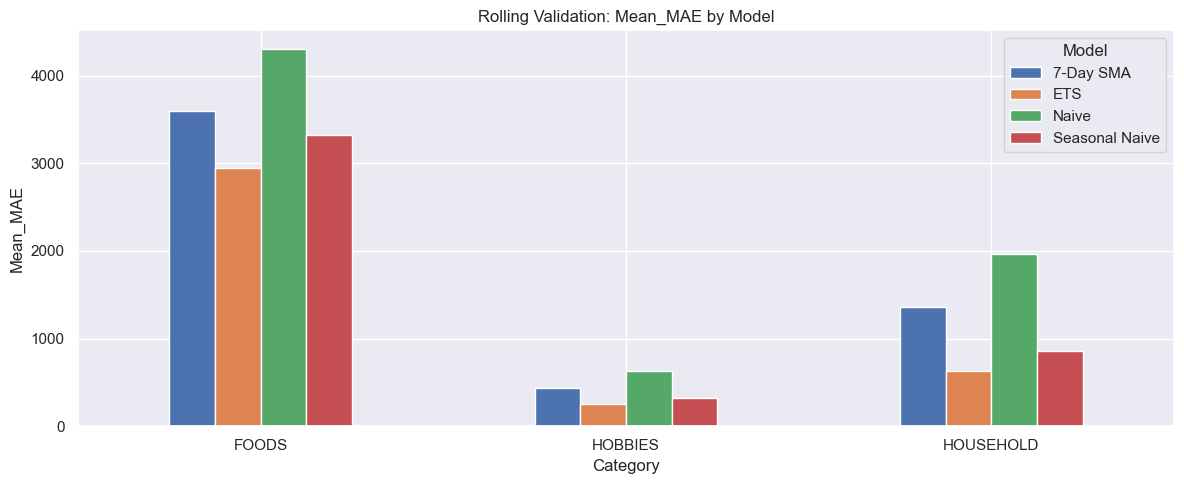

In [23]:
plot_validation_metric(
    validation_summary,
    metric="Mean_MAE"
)

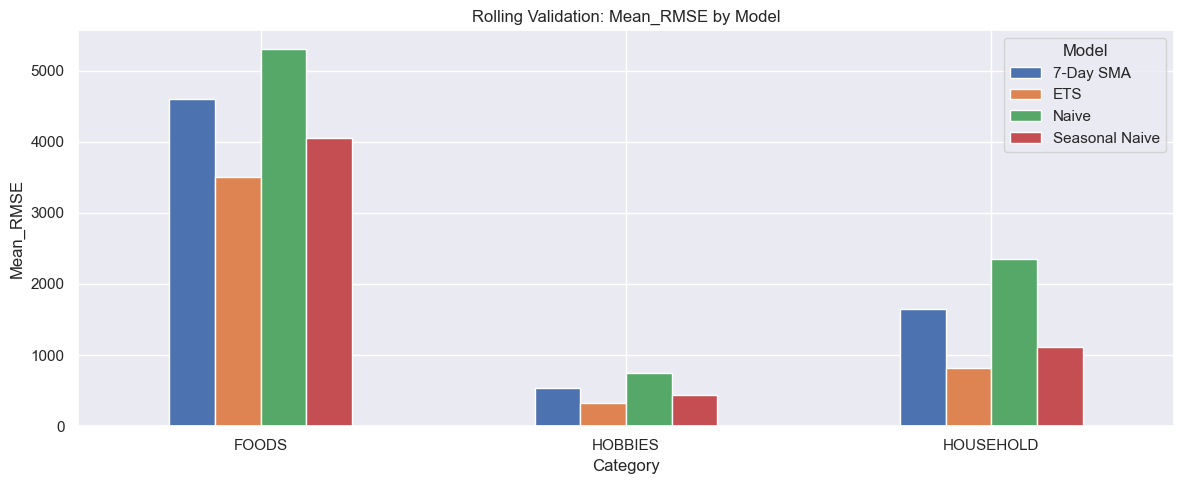

In [24]:
plot_validation_metric(
    validation_summary,
    metric="Mean_RMSE"
)

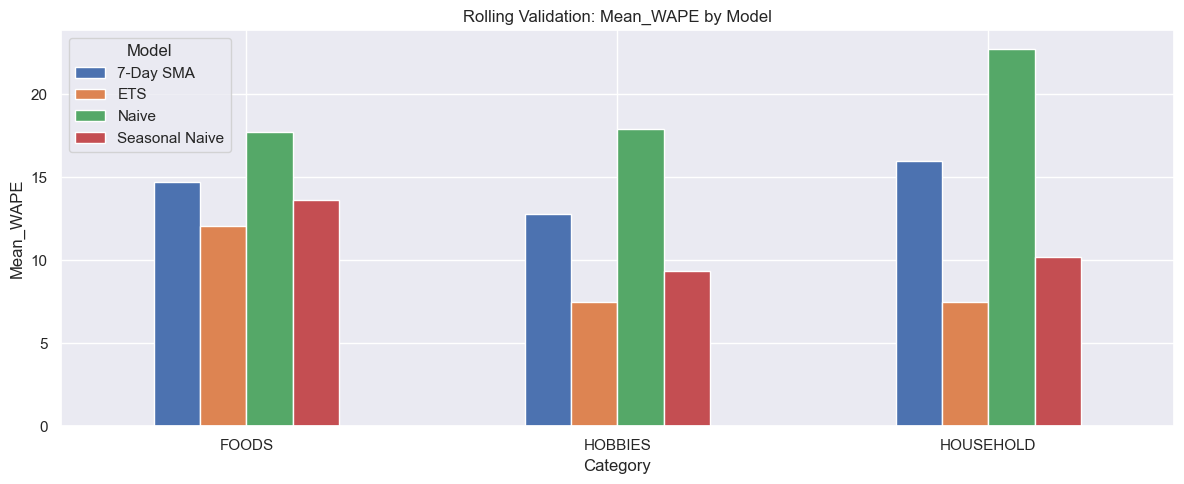

In [25]:
plot_validation_metric(
    validation_summary,
    metric="Mean_WAPE"
)

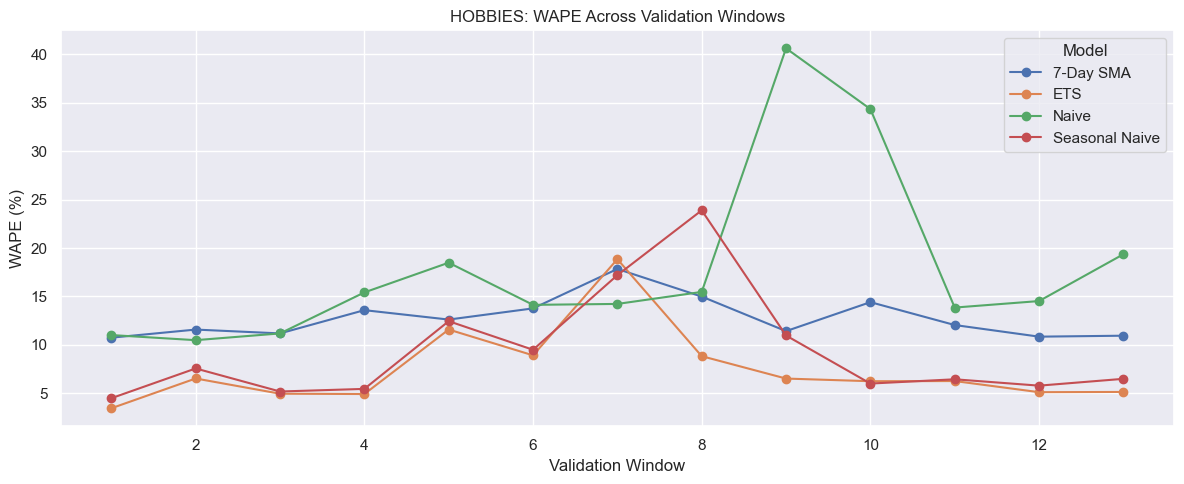

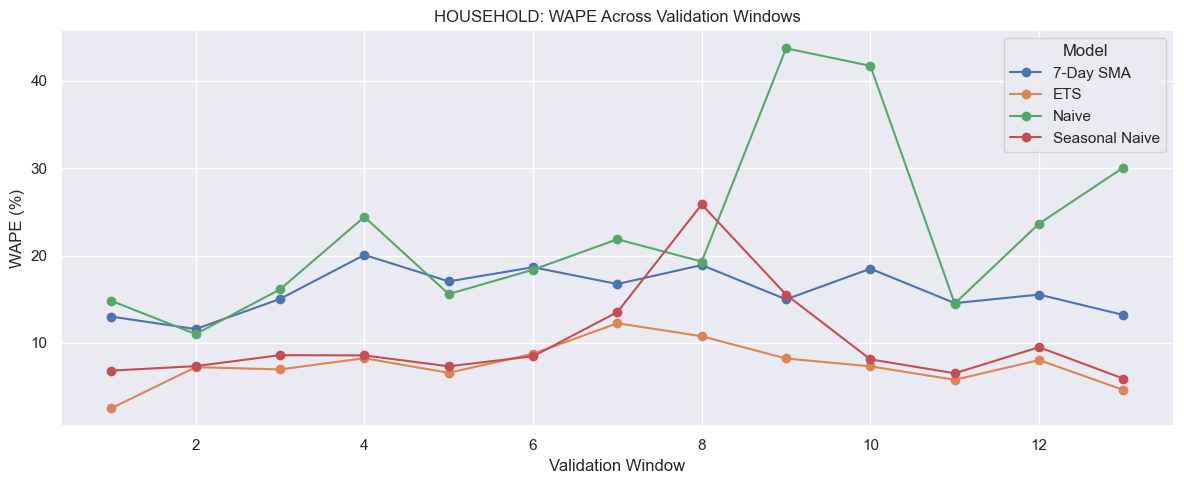

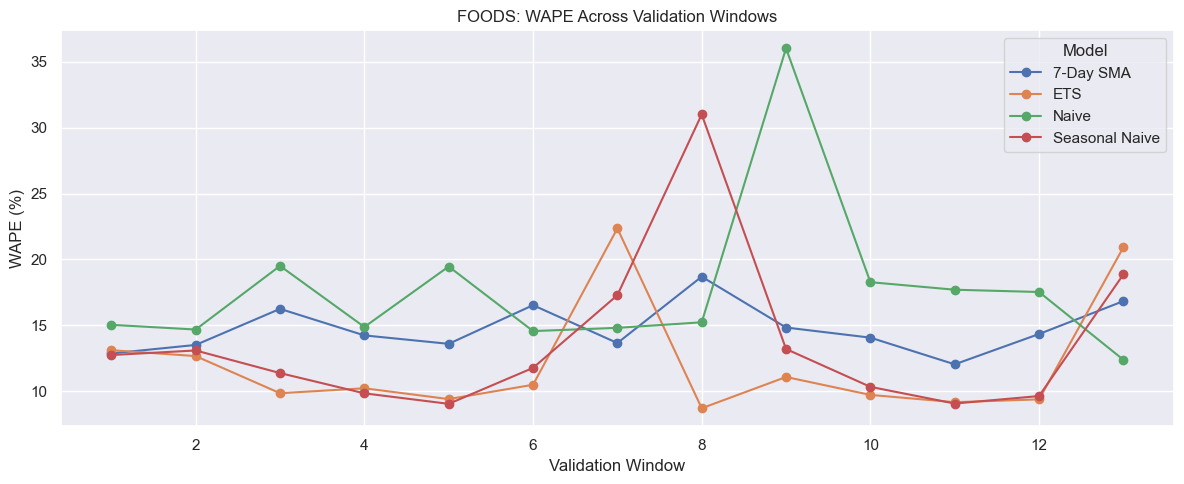

In [26]:
for category in validation_metrics["cat_id"].unique():

    category_results = validation_metrics[
        validation_metrics["cat_id"] == category
    ]

    comparison = category_results.pivot(
        index="window",
        columns="Model",
        values="WAPE (%)"
    )

    ax = comparison.plot(
        marker="o",
        figsize=(12, 5)
    )

    ax.set_title(f"{category}: WAPE Across Validation Windows")
    ax.set_xlabel("Validation Window")
    ax.set_ylabel("WAPE (%)")
    ax.legend(title="Model")

    plt.tight_layout()
    plt.show()

In [29]:
best_models = (
    validation_summary
    .sort_values(
        ["cat_id", "Mean_WAPE"]
    )
    .groupby(
        "cat_id",
        observed=True
    )
    .first()
    .reset_index()
)

best_models = best_models[
    [
        "cat_id",
        "Model",
        "Mean_MAE",
        "Mean_RMSE",
        "Mean_WAPE"
    ]
]

best_models

,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE
0,FOODS,ETS,2944.02,3502.47,12.09
1,HOBBIES,ETS,256.19,332.28,7.50
2,HOUSEHOLD,ETS,629.27,824.15,7.49


In [30]:
best_validation_forecasts = (
    validation_forecasts
    .merge(
        best_models[
            ["cat_id", "Model"]
        ],
        on=["cat_id", "Model"],
        how="inner"
    )
    .sort_values(
        ["cat_id", "ds"]
    )
    .reset_index(drop=True)
)

best_validation_forecasts.head()

,cat_id,window,ds,Model,actual,forecast
0,FOODS,1,2014-06-21,ETS,28669.0,31028.945758
1,FOODS,1,2014-06-22,ETS,29067.0,31586.319423
2,FOODS,1,2014-06-23,ETS,22832.0,25402.372377
3,FOODS,1,2014-06-24,ETS,20933.0,23651.644827
4,FOODS,1,2014-06-25,ETS,19372.0,22871.391156


In [31]:
best_validation_forecasts.groupby(
    "cat_id",
    observed=True
).agg(
    rows=("ds", "size"),
    unique_dates=("ds", "nunique"),
    start=("ds", "min"),
    end=("ds", "max")
)

,rows,unique_dates,start,end
cat_id,,,,
FOODS,365,365,2014-06-21,2015-06-20
HOBBIES,365,365,2014-06-21,2015-06-20
HOUSEHOLD,365,365,2014-06-21,2015-06-20


In [32]:
best_validation_metrics = (
    best_validation_forecasts
    .groupby(
        ["cat_id", "Model"],
        observed=True
    )
    .apply(
        models_metrics.calculate_forecast_metrics,
        forecast_col="forecast",
        actual_col="actual"
    )
    .reset_index()
)

best_validation_metrics.round(2)

/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_69027/3649724809.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,cat_id,Model,MAE,RMSE,WAPE (%)
0,FOODS,ETS,2859.76,3605.42,11.77
1,HOBBIES,ETS,266.55,379.23,7.76
2,HOUSEHOLD,ETS,658.53,891.28,7.75


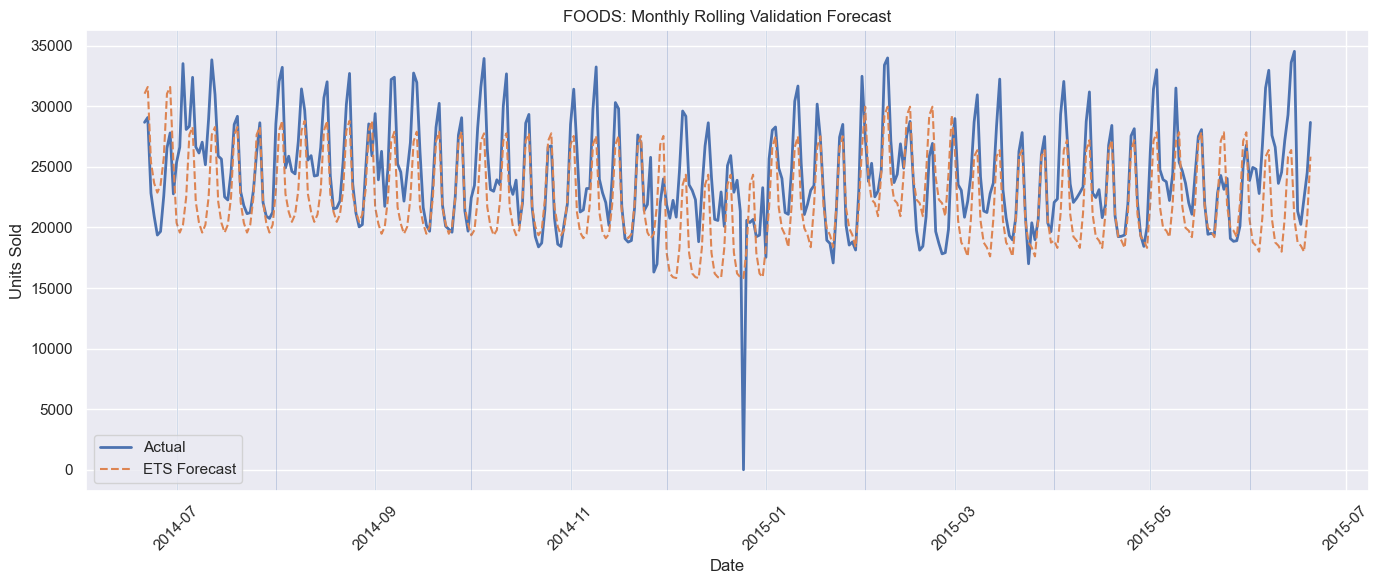

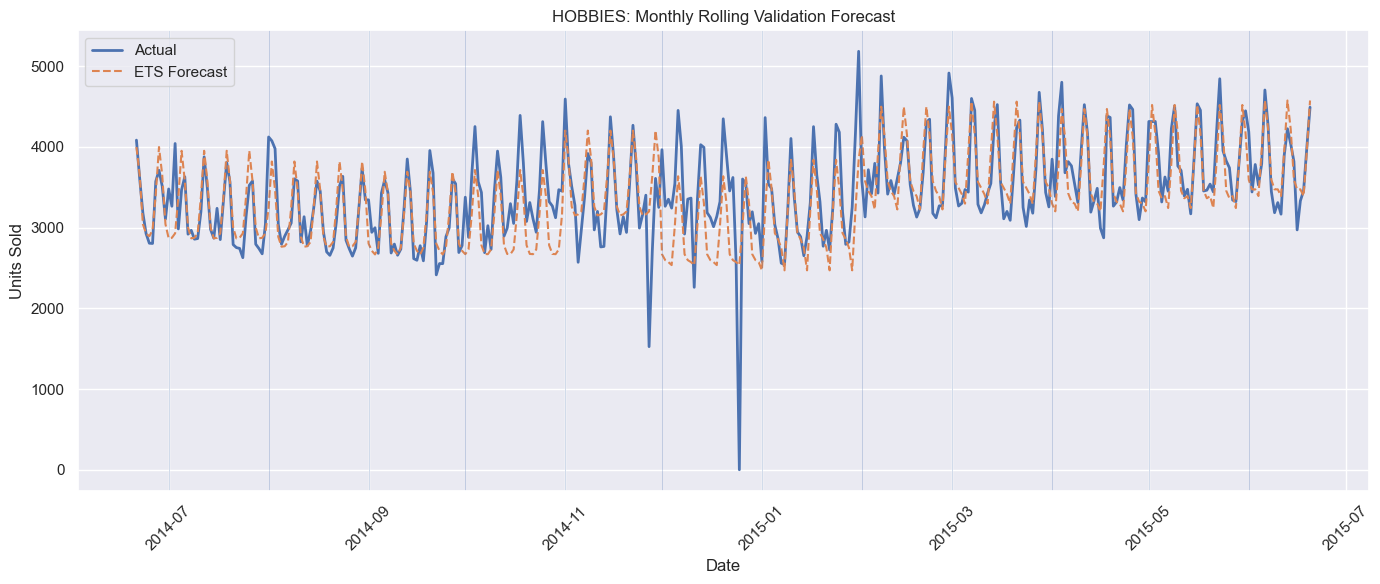

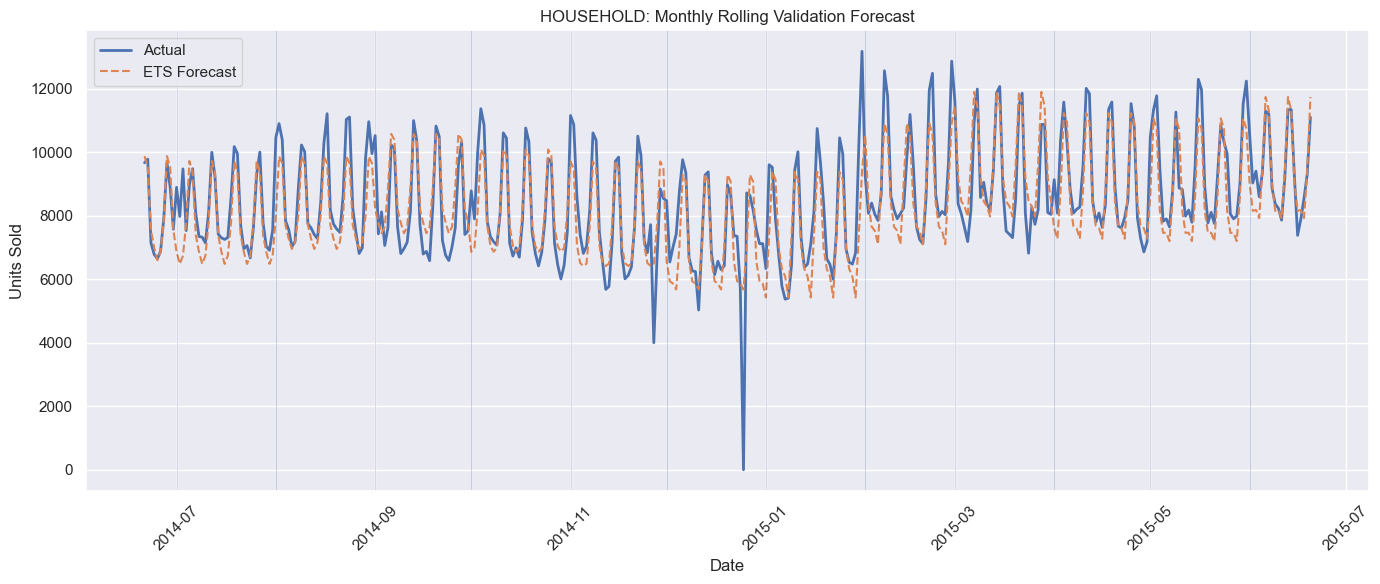

In [33]:
for category, plot_data in (
    best_validation_forecasts
    .groupby("cat_id", observed=True)
):
    model_name = plot_data["Model"].iloc[0]

    plt.figure(figsize=(14, 6))

    plt.plot(
        plot_data["ds"],
        plot_data["actual"],
        label="Actual",
        linewidth=2
    )

    plt.plot(
        plot_data["ds"],
        plot_data["forecast"],
        label=f"{model_name} Forecast",
        linestyle="--"
    )

    # Show where each monthly model refit begins
    for window_start in (
        plot_data
        .groupby("window")["ds"]
        .min()
        .iloc[1:]
    ):
        plt.axvline(
            window_start,
            linewidth=0.6,
            alpha=0.3
        )

    plt.title(
        f"{category}: Monthly Rolling Validation Forecast"
    )
    plt.xlabel("Date")
    plt.ylabel("Units Sold")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [28]:
validation_summary.to_parquet(
    "data/processed/rolling_28d_validation_summary.parquet",
    index=False
)

validation_metrics.to_parquet(
    "data/processed/rolling_28d_validation_metrics.parquet",
    index=False
)

validation_forecasts.to_parquet(
    "data/processed/rolling_28d_validation_forecasts.parquet",
    index=False
)

## Forecast Validation Conclusion

Across the rolling validation windows, ETS produced the lowest overall forecast errors and is currently the strongest model for this retail demand forecasting project.

ETS performed better because it does not rely on a single previous observation or repeat the prior week's demand exactly. Instead, it continuously updates the estimated demand level while accounting for trend and recurring weekly seasonality.

The Seasonal Naive model captured the day-of-week pattern well and often came closer to the highest sales periods. However, because it repeats the previous week's values directly, it also tended to overestimate lower-demand periods when the prior week was unusually strong.

ETS produced a more balanced forecast. It did not always capture the exact highest peak or lowest trough, but it followed the overall demand pattern more consistently and avoided some of the larger errors. For operational forecasting, consistently staying close to actual demand is generally more valuable than perfectly matching isolated peaks while producing larger errors elsewhere.

Based on the current results, ETS is the leading candidate. It must still be evaluated once on the untouched test period after model selection is complete. The next stage will compare it against:

The next models will test whether calendar and event features better capture ETS limitations, including the December 25 demand drop.

- **Prophet**, a time-series forecasting model
- **Linear Regression**, to assess how a simple feature-based model fits the data
- **XGBoost or another tree-based model**, using lag, rolling, calendar, and event features.

This project will remain focused on retail demand forecasting. Product allocation and replenishment decisions will be developed as a separate project, where the selected forecasting model can later be used as an input.